In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("diabetes.csv")

print(df.shape)
df.head()

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Exploratory Data Analysis (EDA)

The dataset contains 768 patient records from the National Institute of Diabetes and Digestive and Kidney Diseases. All patients are female, at least 21 years old, and of Pima Indian heritage. The target variable `Outcome` is binary: 0 (no diabetes) and 1 (diabetes).

Before building any model, we need to understand the shape of the data, the distribution of each feature, and critically — the quality of the data. Several features in this dataset use **0 as a placeholder for missing values**, which is medically impossible (e.g., a BMI of 0, or a blood pressure of 0). Identifying and handling these will be a key part of this EDA.

### EDA Goals
1. **Structure check** — dtypes, nulls, basic stats
2. **Target distribution** — is the dataset balanced or skewed?
3. **Feature distributions** — shape, skew, outliers
4. **Zero-value audit** — identify biologically impossible zeros
5. **Correlation analysis** — relationships between features and the target
6. **Train/test split** — stratified to preserve class balance

In [3]:
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nBasic Statistics:\n")
df.describe()

Shape: (768, 9)

Data Types:
 Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Missing Values:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Basic Statistics:



,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### Zero-Value Audit

Several features use `0` as a placeholder for missing data, which is biologically impossible. `Pregnancies` is excluded from this audit as zero pregnancies is a valid value.

We will count the zeros in each affected column, assess the extent of the problem, and impute using the **median** (more robust than mean for skewed distributions).

Columns requiring audit: `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`


In [4]:
zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in zero_cols:
    zero_count = (df[col] == 0).sum()
    pct = (zero_count / len(df)) * 100
    print(f"{col}: {zero_count} zeros ({pct:.1f}%)")

Glucose: 5 zeros (0.7%)
BloodPressure: 35 zeros (4.6%)
SkinThickness: 227 zeros (29.6%)
Insulin: 374 zeros (48.7%)
BMI: 11 zeros (1.4%)


### Handling Missing Values (Zero Imputation)

Zeros in biologically impossible columns are replaced with the **column median**. Median is preferred over mean here because several of these distributions are right-skewed (as we will see in the distribution plots), making the median a more representative central value.

Note: `Insulin` has 48.7% missing values. Median imputation here is a pragmatic choice but introduces significant artificial concentration around one value. Its importance as a feature should be interpreted cautiously.

In [5]:
for col in zero_cols:
    median_val = df[col].median()
    df[col] = df[col].replace(0, median_val)

print("Remaining zeros after imputation:")
for col in zero_cols:
    print(f"{col}: {(df[col] == 0).sum()}")


Remaining zeros after imputation:
Glucose: 0
BloodPressure: 0
SkinThickness: 0
Insulin: 0
BMI: 0


### Target Distribution

Before looking at features, we check the balance of the target variable `Outcome`. Class imbalance — where one outcome significantly outnumbers the other — can bias a model toward always predicting the majority class, producing deceptively high accuracy with poor real-world utility.

/tmp/ipykernel_3194/2909163789.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Outcome", data=df, ax=axes[0], palette="Blues")
/tmp/ipykernel_3194/2909163789.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["No Diabetes (0)", "Diabetes (1)"])


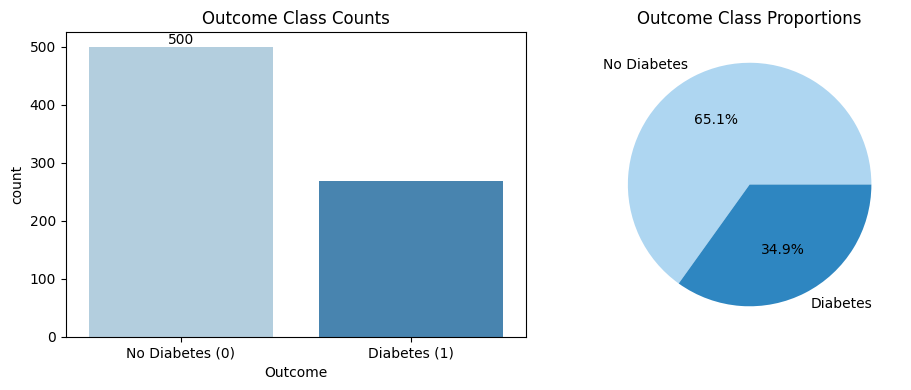

Outcome
0    500
1    268
Name: count, dtype: int64

Class ratio: 1.87:1


In [6]:
figs, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.countplot(x="Outcome", data=df, ax=axes[0], palette="Blues")
axes[0].set_title("Outcome Class Counts")
axes[0].set_xticklabels(["No Diabetes (0)", "Diabetes (1)"])
axes[0].bar_label(axes[0].containers[0])

outcome_counts = df["Outcome"].value_counts()
axes[1].pie(outcome_counts, labels=["No Diabetes", "Diabetes"], autopct="%1.1f%%", colors=["#AED6f1", "#2E86C1"])
axes[1].set_title("Outcome Class Proportions")

plt.tight_layout()
plt.show()

print(df["Outcome"].value_counts())
print(f"\nClass ratio: {outcome_counts[0]/outcome_counts[1]:.2f}:1")

### Feature Distributions

We plot the distribution of each feature to understand shape, skew, and the presence of outliers. This informs us how each variable behaves and whether any transformations might be needed before modeling.

Decision trees are not sensitive to feature scale or skew the way linear models are — they split on thresholds, not magnitudes. However, understanding distributions helps us interpret the model's decisions and spot any remaining data quality issues.

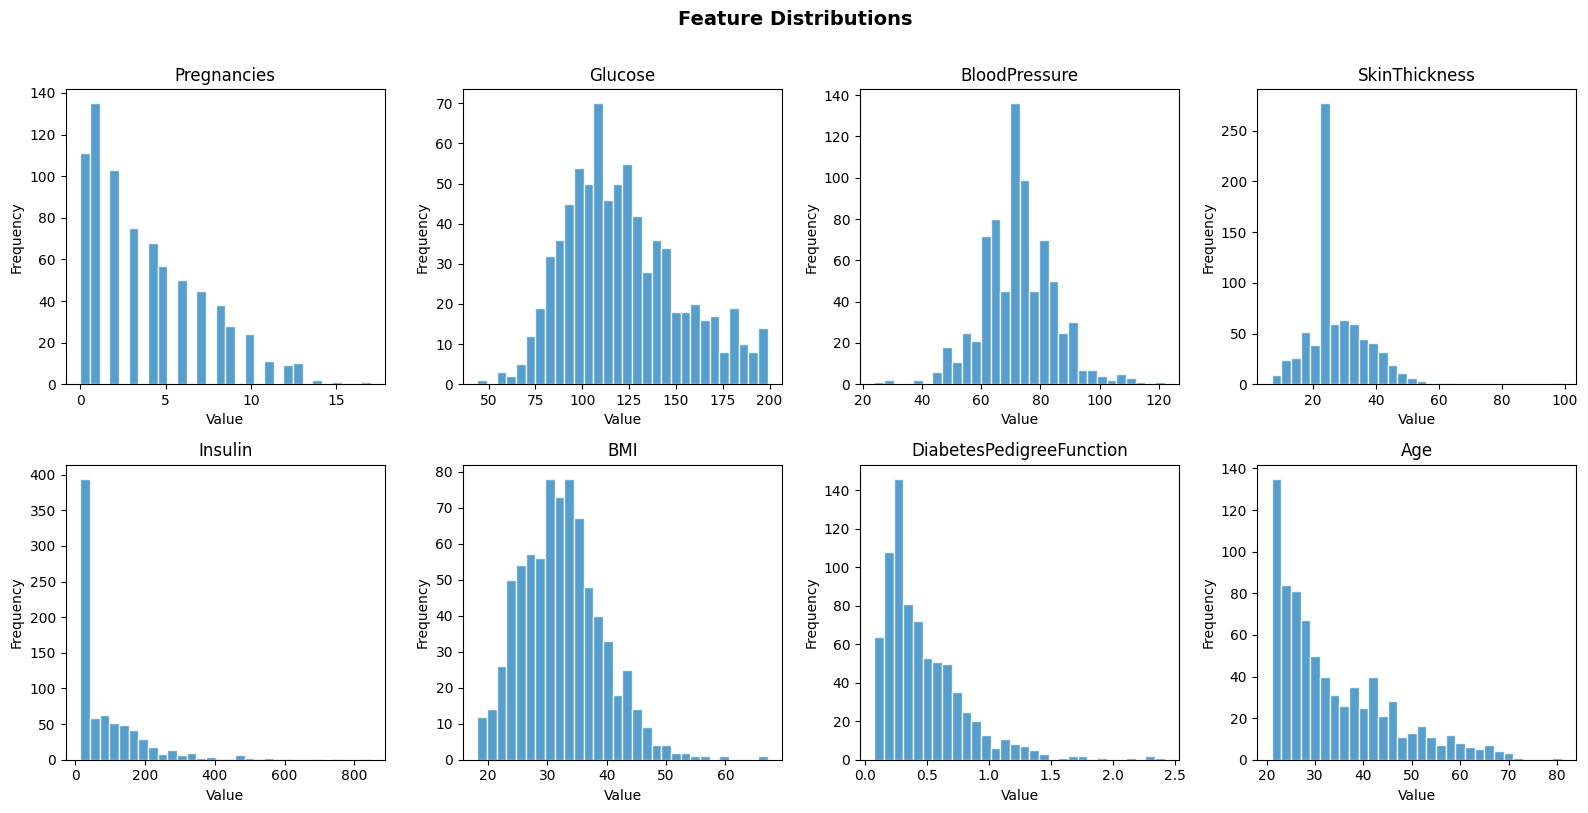

In [8]:
features = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df[col], bins=30, color="#2E86C1", edgecolor="white", alpha=0.8)
    axes[i].set_title(col)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")

plt.suptitle("Feature Distributions", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### Correlation Analysis

From the distribution plots, we can already see that `Glucose` and `BMI` have the most normal, well-distributed shapes — these are likely to be strong predictors. `Insulin` and `SkinThickness` both show severe imputation artifacts (spikes at their median values), which will artificially suppress their correlations with `Outcome` since nearly half and a third of their values respectively are identical.

We now examine the full correlation matrix to quantify these relationships. We are looking for:
- **High feature-target correlation**: features that move meaningfully with `Outcome` — these will be the tree's preferred split points
- **High feature-feature correlation**: pairs of features that carry redundant information — the tree will naturally favor one over the other, potentially making the other irrelevant
- **Low correlation across the board**: would suggest the dataset is noisy and the model will need to work harder to find signal

/tmp/ipykernel_3194/3355820535.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_corr.values, y=target_corr.index, ax=axes[1], palette="Blues_r")


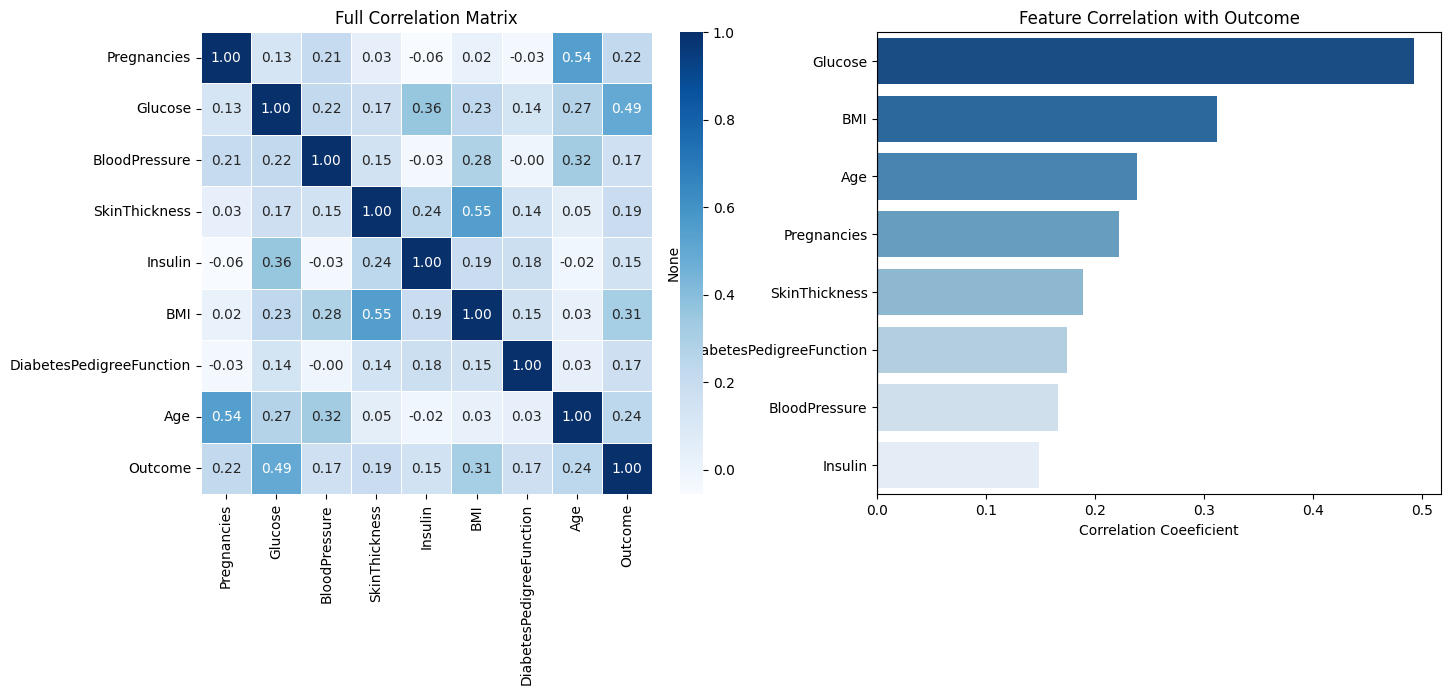

Glucose                     0.492782
BMI                         0.312249
Age                         0.238356
Pregnancies                 0.221898
SkinThickness               0.189065
DiabetesPedigreeFunction    0.173844
BloodPressure               0.165723
Insulin                     0.148457
Name: Outcome, dtype: float64


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="Blues", ax=axes[0], linewidths=0.5)
axes[0].set_title("Full Correlation Matrix")

target_corr = df.corr()["Outcome"].drop("Outcome").sort_values(ascending=False)
sns.barplot(x=target_corr.values, y=target_corr.index, ax=axes[1], palette="Blues_r")
axes[1].set_title("Feature Correlation with Outcome")
axes[1].set_xlabel("Correlation Coeeficient")
axes[1].axvline(x=0, color="black", linewidth=0.8)

plt.tight_layout
plt.show()

print(target_corr)

### Train/Test Split

EDA is complete. The data is clean, imputed, and understood. Key takeaways going into modeling:
- `Glucose` is the strongest single predictor at 0.49 correlation with `Outcome`
- `BMI`, `Age`, and `Pregnancies` form a meaningful second tier
- `Insulin` and `SkinThickness` are compromised by heavy imputation and will likely contribute little
- No feature pairs are correlated strongly enough (>0.7) to justify dropping either on redundancy grounds alone

We now split 80/20 into train and test sets. `stratify=Outcome` is used to guarantee that the 65/35 class imbalance is preserved proportionally in both sets — without this, random sampling could skew one set toward the majority class and make evaluation misleading.

In [13]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"\nTrain class distribution:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"\nTest class distribution:\n{y_test.value_counts(normalize=True).round(3)}")

X_train: (614, 8)
X_test: (154, 8)

Train class distribution:
Outcome
0    0.651
1    0.349
Name: proportion, dtype: float64

Test class distribution:
Outcome
0    0.649
1    0.351
Name: proportion, dtype: float64


## Model Building — Decision Tree Classifier

EDA gave us a clear picture of what the model is working with: a moderately imbalanced dataset (65/35), a dominant predictor in `Glucose`, a solid second tier in `BMI`, `Age`, and `Pregnancies`, and two compromised features in `Insulin` and `SkinThickness`. The decision tree will have to learn to navigate this signal landscape on its own.

Decision trees split data recursively on feature thresholds, choosing the split at each node that best separates the classes. What "best" means depends on the **purity function** used:

- **Gini impurity**: How often a randomly chosen sample would be misclassified at this node. Fast and tends to isolate the most frequent class early.
- **Entropy**: Measures information disorder at a node — how much uncertainty remains after the split. Slightly more sensitive to class balance than Gini.
- **Log Loss**: Penalizes confident wrong predictions most heavily. More cautious in uncertain regions of the feature space.

Given our class imbalance and the known weakness of `Insulin` and `SkinThickness`, the choice of purity function may meaningfully affect how the tree handles the minority class (diabetes positive). We will train a baseline tree under all three criteria and compare before committing to one for optimization.

In [16]:
criteria = ["gini", "entropy", "log_loss"]
baseline_models = {}

for criterion in criteria:
    model = DecisionTreeClassifier(criterion=criterion, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    baseline_models[criterion] = {
        "model": model,
        "y_pred": y_pred, 
        "accuracy": accuracy_score(y_test, y_pred)
    }

    print(f"\n{'='*40}")
    print(f"Criterion: {criterion.upper()}")
    print(f"Accuracy: {baseline_models[criterion]['accuracy']:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=["No Diabetes", "Diabetes"]))


Criterion: GINI
Accuracy: 0.6688

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.72      0.79      0.76       100
    Diabetes       0.53      0.44      0.48        54

    accuracy                           0.67       154
   macro avg       0.63      0.62      0.62       154
weighted avg       0.66      0.67      0.66       154


Criterion: ENTROPY
Accuracy: 0.6623

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.74      0.73      0.74       100
    Diabetes       0.52      0.54      0.53        54

    accuracy                           0.66       154
   macro avg       0.63      0.63      0.63       154
weighted avg       0.67      0.66      0.66       154


Criterion: LOG_LOSS
Accuracy: 0.6623

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.74      0.73      0.74       100
    Diabetes       0.52      0.54      0.53        54

 

### Baseline Model Comparison

All three criteria produced similar results on an untuned tree, confirming that the baseline performance (~66-67% accuracy) reflects the difficulty of the problem rather than the choice of purity function. The key differentiator is recall on the positive class (diabetes): Gini caught only 44% of true diabetes cases versus 54% for both entropy and log_loss. In a medical diagnostic context, false negatives — missed diabetes diagnoses — carry significantly higher real-world cost than false positives. On this basis, **entropy** is selected as the criterion for optimization. Entropy and log_loss produced identical results; entropy is preferred for its well-established theoretical grounding in information gain.

In [18]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [3, 4, 5, 6, 7, 8, 10, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": [None, "sqrt", "log2"]
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(criterion="entropy", random_state=42),
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV F1 Score: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 384 candidates, totalling 1920 fits


Best Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 8, 'min_samples_split': 2}
Best CV F1 Score: 0.6351


### Optimized Decision Tree

Grid search evaluated 384 parameter combinations across 5-fold cross validation (1920 total fits) to find the configuration that maximizes F1 on the training data. F1 was chosen as the scoring metric rather than accuracy to force the search to balance precision and recall on the minority diabetes class — accuracy alone would reward a tree that simply over-predicts "no diabetes."

The winning configuration constrains the tree in three meaningful ways: `max_depth=10` prevents unlimited growth, `min_samples_leaf=8` stops the tree from creating leaf nodes with fewer than 8 samples (directly targeting the overfitting we saw in the baseline), and `max_features=sqrt` limits each split to considering only ~3 of the 8 features at random — a technique borrowed from random forests that reduces variance. Together these act as guardrails against the memorization behavior we saw in the untuned baseline models.

We now run the optimized model against the held-out test set to see whether these constraints translate to real improvement.

Optimized Model Accuracy: 0.7013

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.72      0.88      0.79       100
    Diabetes       0.62      0.37      0.47        54

    accuracy                           0.70       154
   macro avg       0.67      0.63      0.63       154
weighted avg       0.69      0.70      0.68       154



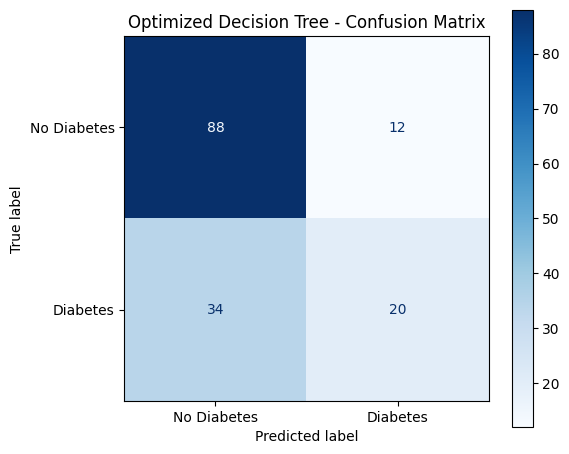

In [20]:
best_model = grid_search.best_estimator_

y_pred_optimized = best_model.predict(X_test)

print(f"Optimized Model Accuracy: {accuracy_score(y_test, y_pred_optimized):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_optimized, target_names=["No Diabetes", "Diabetes"]))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_optimized, display_labels=["No Diabetes", "Diabetes"], cmap="Blues", ax=ax)
ax.set_title("Optimized Decision Tree - Confusion Matrix")
plt.tight_layout()
plt.show()

### Optimized Model Evaluation

The optimized model improved overall accuracy from 66.2% to 70.1%, but this came at a cost: recall on the diabetes positive class dropped from 0.54 (baseline entropy) to 0.37. Of 54 actual diabetes cases in the test set, 34 were misclassified as negative. This reflects the core challenge of imbalanced classification — the optimizer found a configuration that performs better globally while becoming more conservative about predicting the minority class.

To address this directly, we rerun the grid search with `class_weight="balanced"` added to the estimator. This instructs the tree to penalize misclassification of the minority class (diabetes positive) proportionally to its underrepresentation in the dataset — in this case roughly doubling the cost of a false negative. The goal is to recover recall on the positive class without abandoning the accuracy gains from optimization.

Fitting 5 folds for each of 384 candidates, totalling 1920 fits
Best Parameters: {'max_depth': 6, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 5}
Best CV F1 Score: 0.6630
Optimized Balanced Model Accuracy: 0.7857

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.94      0.72      0.81       100
    Diabetes       0.64      0.91      0.75        54

    accuracy                           0.79       154
   macro avg       0.79      0.81      0.78       154
weighted avg       0.83      0.79      0.79       154



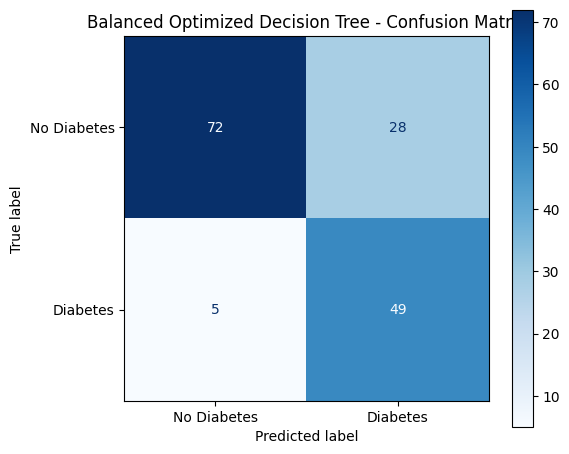

In [21]:
grid_search_balanced = GridSearchCV(
    DecisionTreeClassifier(criterion="entropy", random_state=42, class_weight="balanced"),
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

grid_search_balanced.fit(X_train, y_train)

best_model_balanced = grid_search_balanced.best_estimator_
y_pred_balanced = best_model_balanced.predict(X_test)

print(f"Best Parameters: {grid_search_balanced.best_params_}")
print(f"Best CV F1 Score: {grid_search_balanced.best_score_:.4f}")
print(f"Optimized Balanced Model Accuracy: {accuracy_score(y_test, y_pred_balanced):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_balanced, target_names=["No Diabetes", "Diabetes"]))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_balanced, display_labels=["No Diabetes", "Diabetes"], cmap="Blues", ax=ax)
ax.set_title("Balanced Optimized Decision Tree - Confusion Matrix")
plt.tight_layout()
plt.show()

### Further Refinement — Decision Threshold Optimization

The balanced model achieved strong recall (0.91) but introduced 28 false positives — healthy patients incorrectly flagged as diabetic. This is an inherent consequence of pushing the model to be aggressive about catching the minority class.

Every classifier outputs a probability score via `predict_proba` before converting it to a class label. By default, scikit-learn uses 0.5 as the decision boundary — any probability above 0.5 becomes a positive prediction. This threshold is arbitrary and rarely optimal.

By plotting the **Precision-Recall curve** across all possible thresholds, we can visualize the full tradeoff landscape and select the threshold that best serves our objective — in this case, maintaining high recall on the diabetes class while recovering some of the precision lost to false positives. This is standard practice in production classification systems where the cost of each error type is asymmetric.`

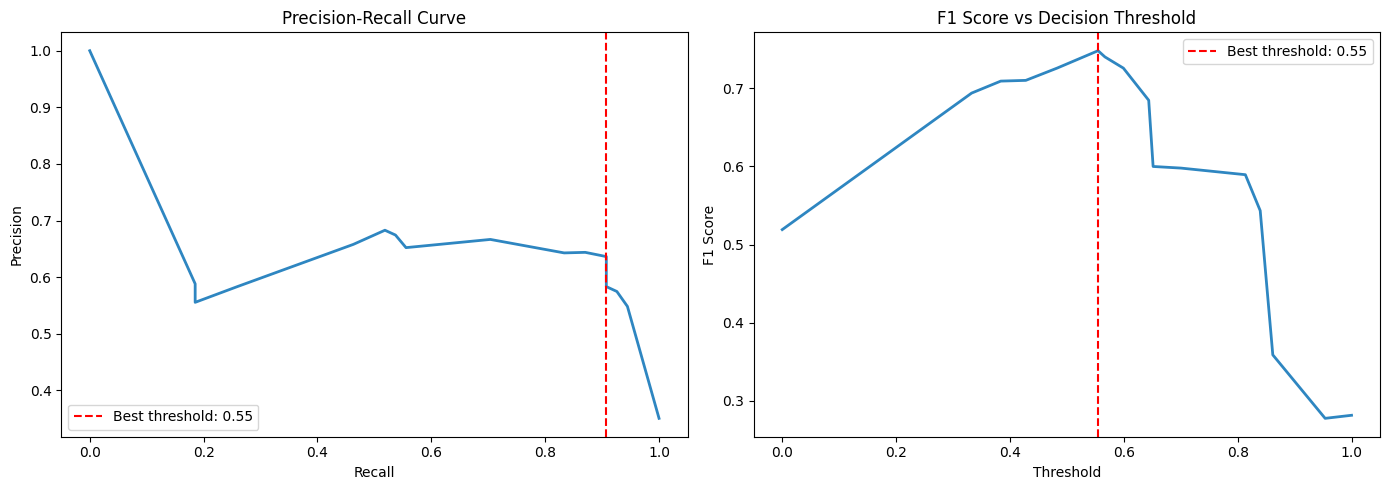

Best F1 threshold: 0.5548
Precision at best threshold: 0.6364
Recall at best threshold:    0.9074
F1 at best threshold:        0.7481


In [23]:
from sklearn.metrics import precision_recall_curve, auc

y_proba_balanced = best_model_balanced.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_balanced)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_threshold_idx = f1_scores.argmax()
best_threshold = thresholds[best_threshold_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(recalls, precisions, color="#2E86C1", linewidth=2)
axes[0].axvline(x=recalls[best_threshold_idx], color="red", linestyle="--", label=f"Best threshold: {best_threshold:.2f}")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("Precision-Recall Curve")
axes[0].legend()

axes[1].plot(thresholds, f1_scores[:-1], color="#2E86C1", linewidth=2)
axes[1].axvline(x=best_threshold, color="red", linestyle="--", label=f"Best threshold: {best_threshold:.2f}")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("F1 Score")
axes[1].set_title("F1 Score vs Decision Threshold")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Best F1 threshold: {best_threshold:.4f}")
print(f"Precision at best threshold: {precisions[best_threshold_idx]:.4f}")
print(f"Recall at best threshold:    {recalls[best_threshold_idx]:.4f}")
print(f"F1 at best threshold:        {f1_scores[best_threshold_idx]:.4f}")

Threshold Applied: 0.5548

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.94      0.72      0.81       100
    Diabetes       0.64      0.91      0.75        54

    accuracy                           0.79       154
   macro avg       0.79      0.81      0.78       154
weighted avg       0.83      0.79      0.79       154



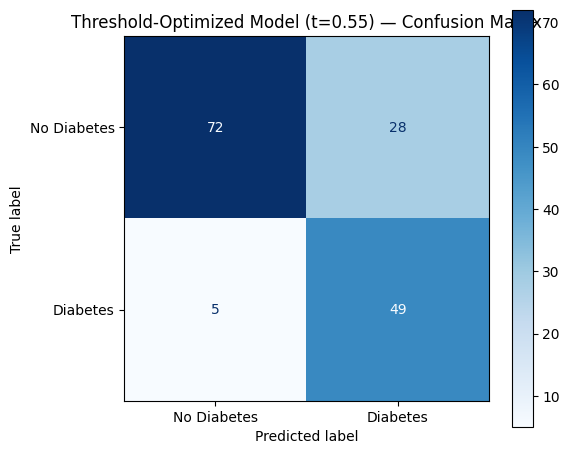

In [24]:
y_pred_threshold = (y_proba_balanced >= best_threshold).astype(int)

print(f"Threshold Applied: {best_threshold:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_threshold, target_names=["No Diabetes", "Diabetes"]))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_threshold, display_labels=["No Diabetes", "Diabetes"], cmap="Blues", ax=ax)
ax.set_title(f"Threshold-Optimized Model (t={best_threshold:.2f}) — Confusion Matrix")
plt.tight_layout()
plt.show()

### Threshold Optimization Results

Applying the F1-optimal threshold of 0.55 produced no change in the confusion matrix relative to the balanced model — no patients in the test set had probability scores in the 0.50–0.55 range, meaning the threshold shift had no practical effect. This confirms that class weighting was the meaningful intervention, and that the remaining 28 false positives represent the ceiling of this model's discriminative ability given the available features. Patients in this ambiguous zone are likely affected by the imputation damage on `Insulin` and `SkinThickness` — the missing data that was replaced with median values during EDA. Further reduction of false positives would require either higher quality source data or a more powerful model architecture. The balanced optimized model is confirmed as our final model.

### Decision Tree Visualization

With the final model selected, we visualize the tree structure itself. This is one of the key advantages of decision trees over more powerful but opaque models like random forests or neural networks — the decision logic is fully inspectable. Every path from root to leaf represents a human-readable set of rules the model learned from the data.

We expect to see `Glucose` dominating the early splits given its 0.49 correlation with `Outcome`, with `BMI` and `Age` appearing in the mid-levels. `Insulin` and `SkinThickness` may appear deeper in the tree or not at all, reflecting the imputation damage identified during EDA.

/tmp/ipykernel_3194/3464519601.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, ax=axes[1], palette="Blues_r")


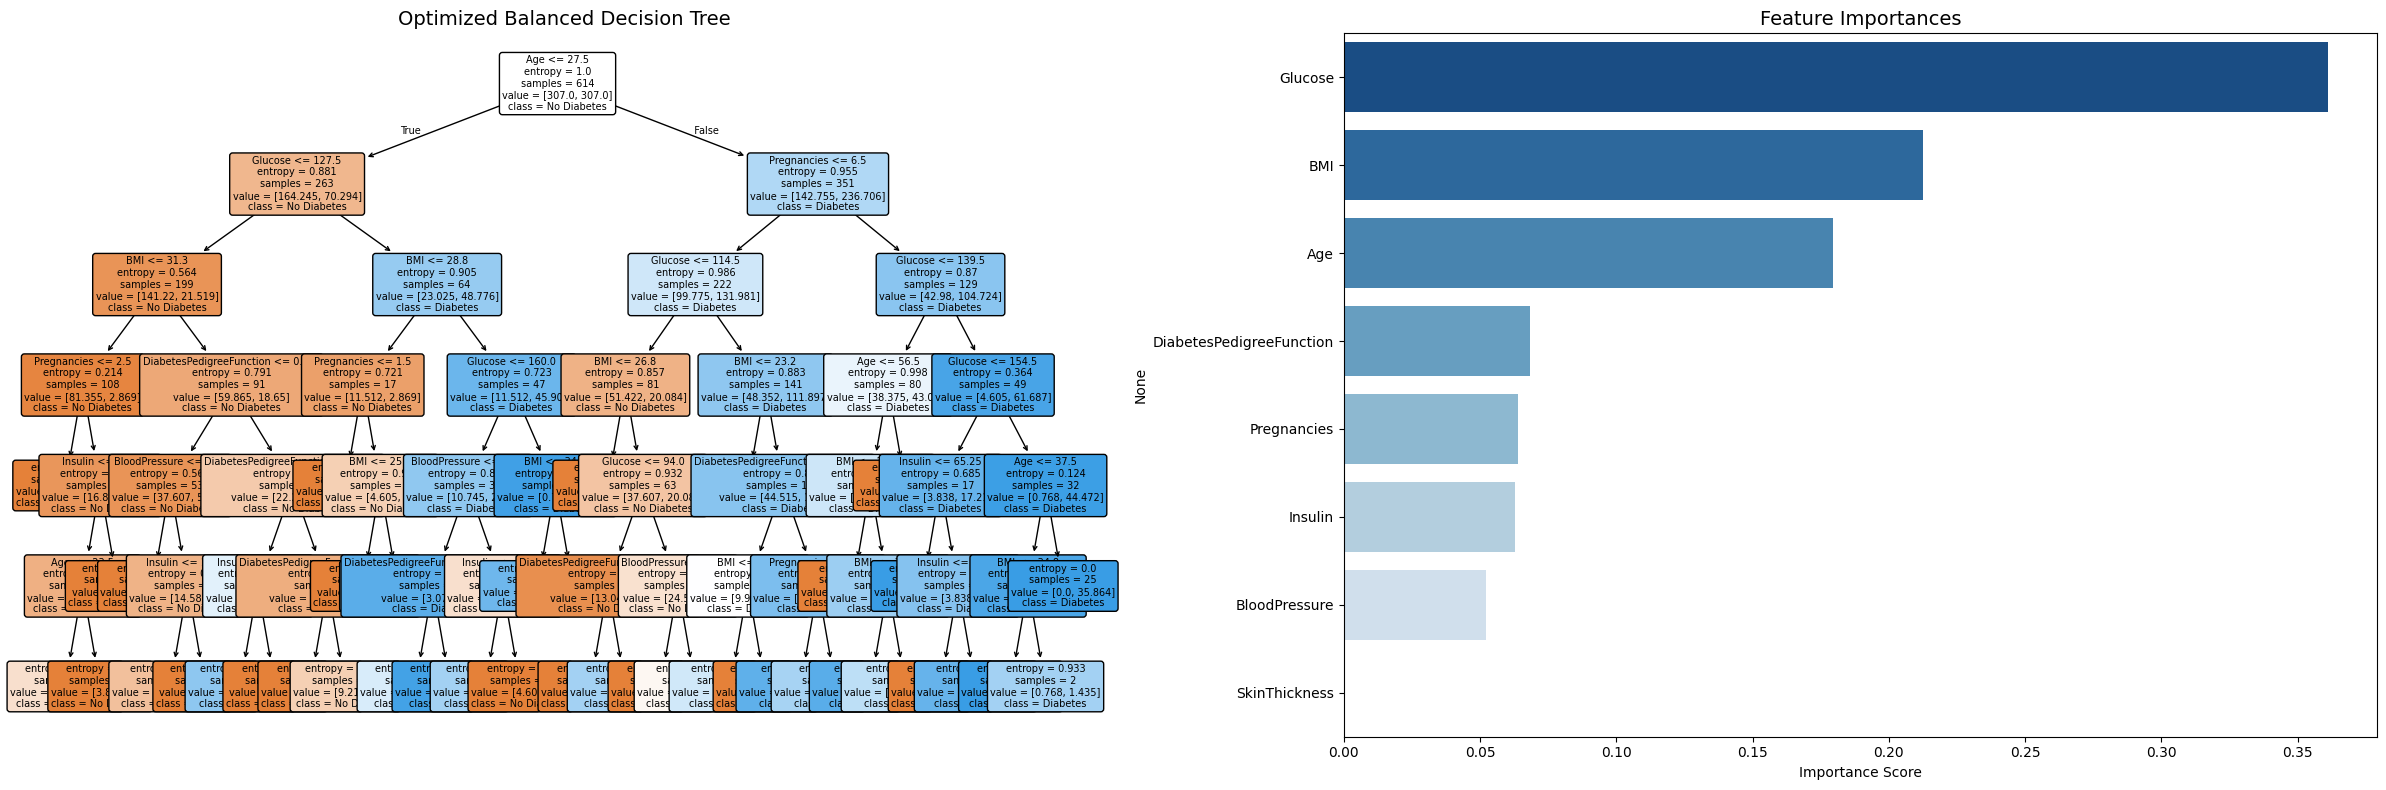


Feature Importances:
Glucose                     0.3611
BMI                         0.2126
Age                         0.1794
DiabetesPedigreeFunction    0.0682
Pregnancies                 0.0639
Insulin                     0.0628
BloodPressure               0.0521
SkinThickness               0.0000
dtype: float64


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(24, 8))

plot_tree(
    best_model_balanced,
    feature_names=X.columns.tolist(),
    class_names=["No Diabetes", "Diabetes"],
    filled=True,
    rounded=True,
    fontsize=7,
    ax=axes[0]
)
axes[0].set_title("Optimized Balanced Decision Tree", fontsize=14)

importances = pd.Series(best_model_balanced.feature_importances_, index=X.columns).sort_values(ascending=False)
sns.barplot(x=importances.values, y=importances.index, ax=axes[1], palette="Blues_r")
axes[1].set_title("Feature Importances", fontsize=14)
axes[1].set_xlabel("Importance Score")

plt.tight_layout()
plt.show()

print("\nFeature Importances:")
print(importances.round(4))

### Tree Structure and Feature Importance Analysis

The feature importance scores directly validate the findings from EDA. `Glucose` is the dominant predictor at 0.36, followed by `BMI` (0.21) and `Age` (0.18) — precisely the features identified as strongest during correlation analysis. `SkinThickness` received an importance score of exactly 0.00, meaning the tree learned to ignore it entirely — a direct consequence of the 29.6% median imputation identified during the zero-value audit. `Insulin`, compromised by 48.7% imputation, contributed minimally at 0.06.

The root split on `Age <= 27.5` rather than `Glucose` reflects the influence of class weighting — the balanced tree partitions the space differently than a standard tree, using age as an efficient early separator before `Glucose` dominates the deeper levels. This is the tree adapting its structure to the reweighted cost landscape rather than simply chasing majority class accuracy.

The full decision path from root to leaf is human-readable and auditable — a property that distinguishes decision trees from more powerful but opaque architectures.

In [28]:
import pickle
import os

os.makedirs("models", exist_ok=True)

with open("models/decision_tree_diabetes.pkl", "wb") as f:
    pickle.dump(best_model_balanced, f)

with open("models/decision_tree_diabetes.pkl", "rb") as f:
    loaded_model = pickle.load(f)

print("Model saved successfully.")
print(f"Save to: models/decision_tree_diabetes.pkl")
print(f"Verification - loaded model type: {type(loaded_model)}")
print(f"Verification - featured names: {loaded_model.feature_names_in_.tolist()}")

Model saved successfully.
Save to: models/decision_tree_diabetes.pkl
Verification - loaded model type: <class 'sklearn.tree._classes.DecisionTreeClassifier'>
Verification - featured names: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


## Summary

A Decision Tree Classifier was built to predict diabetes diagnosis from the Pima Indian Diabetes dataset. The full pipeline covered:

- **Data quality**: Five features contained biologically impossible zero values encoding missing data. These were identified via zero-value audit and replaced with column medians. `Insulin` (48.7% zeros) and `SkinThickness` (29.6% zeros) were flagged as compromised — a prediction confirmed by the final feature importance scores, where `SkinThickness` scored 0.00 and `Insulin` scored 0.06.

- **Class imbalance**: The dataset is 65/35 negative/positive. A standard optimized tree achieved 70% accuracy but caught only 37% of actual diabetes cases — an unacceptable false negative rate for a medical diagnostic context. Class weighting via `class_weight="balanced"` recovered recall to 91% while simultaneously improving overall accuracy to 78.6%.

- **Threshold optimization**: Precision-Recall curve analysis identified an optimal threshold of 0.55, which produced no additional change — confirming that class weighting had already pushed the model to its practical ceiling given the available data quality.

- **Final model**: Entropy criterion, `class_weight="balanced"`, `max_depth=6`, `max_features=log2`, `min_samples_leaf=2`, `min_samples_split=5`. Accuracy 78.6%, diabetes recall 0.91, F1 0.75. Saved to `models/decision_tree_diabetes.pkl`.